In [ ]:

import pandas as pd

# Load datasets
orders = pd.read_csv('olist_orders_dataset.csv')
items = pd.read_csv('olist_order_items_dataset.csv')
products = pd.read_csv('olist_products_dataset.csv')
customers = pd.read_csv('olist_customers_dataset.csv')
reviews = pd.read_csv('olist_order_reviews_dataset.csv')

# Dataset Shapes
print("=== DATASET SHAPES ===")
print("Orders:", orders.shape)
print("Items:", items.shape)
print("Products:", products.shape)
print("Customers:", customers.shape)
print("Reviews:", reviews.shape)

# Missing Values
print("\n=== MISSING VALUES ===")
print("\nOrders")
print(orders.isnull().sum())

print("\nItems")
print(items.isnull().sum())

print("\nProducts")
print(products.isnull().sum())

print("\nCustomers")
print(customers.isnull().sum())

print("\nReviews")
print(reviews.isnull().sum())

# Duplicate Records
print("\n=== DUPLICATES ===")
print("Orders:", orders.duplicated().sum())
print("Items:", items.duplicated().sum())
print("Products:", products.duplicated().sum())
print("Customers:", customers.duplicated().sum())
print("Reviews:", reviews.duplicated().sum())
import pandas as pd

# Reload datasets
orders = pd.read_csv('olist_orders_dataset.csv')
items = pd.read_csv('olist_order_items_dataset.csv')
products = pd.read_csv('olist_products_dataset.csv')
customers = pd.read_csv('olist_customers_dataset.csv')
reviews = pd.read_csv('olist_order_reviews_dataset.csv')

# Convert dates
orders['order_purchase_timestamp'] = pd.to_datetime(
    orders['order_purchase_timestamp']
)

# Handle missing values
products['product_category_name'] = products[
    'product_category_name'
].fillna('Unknown')

# Remove duplicates (safety)
orders.drop_duplicates(inplace=True)
items.drop_duplicates(inplace=True)
products.drop_duplicates(inplace=True)
customers.drop_duplicates(inplace=True)
reviews.drop_duplicates(inplace=True)

# Merge datasets
sales = orders.merge(items, on='order_id', how='inner')
sales = sales.merge(products, on='product_id', how='left')
sales = sales.merge(customers, on='customer_id', how='left')
sales = sales.merge(reviews[['order_id','review_score']],
                    on='order_id',
                    how='left')

print("Merged Shape:", sales.shape)

sales.head()
import pandas as pd

# Reload datasets
orders = pd.read_csv('olist_orders_dataset.csv')
items = pd.read_csv('olist_order_items_dataset.csv')
products = pd.read_csv('olist_products_dataset.csv')
customers = pd.read_csv('olist_customers_dataset.csv')
reviews = pd.read_csv('olist_order_reviews_dataset.csv')

# Convert dates
orders['order_purchase_timestamp'] = pd.to_datetime(
    orders['order_purchase_timestamp']
)

# Handle missing values
products['product_category_name'] = products[
    'product_category_name'
].fillna('Unknown')

# Remove duplicates (safety)
orders.drop_duplicates(inplace=True)
items.drop_duplicates(inplace=True)
products.drop_duplicates(inplace=True)
customers.drop_duplicates(inplace=True)
reviews.drop_duplicates(inplace=True)

# Merge datasets
sales = orders.merge(items, on='order_id', how='inner')
sales = sales.merge(products, on='product_id', how='left')
sales = sales.merge(customers, on='customer_id', how='left')
sales = sales.merge(reviews[['order_id','review_score']],
                    on='order_id',
                    how='left')

print("Merged Shape:", sales.shape)

sales.head()
# Total Revenue
total_revenue = sales['price'].sum()

# Top Category
top_category = (
    sales.groupby('product_category_name')['price']
    .sum()
    .sort_values(ascending=False)
)

# Monthly Sales
sales['month'] = sales['order_purchase_timestamp'].dt.to_period('M')

monthly_sales = (
    sales.groupby('month')['price']
    .sum()
    .sort_values(ascending=False)
)

# Best Region
region_sales = (
    sales.groupby('customer_state')['price']
    .sum()
    .sort_values(ascending=False)
)

print("Total Revenue:")
print(total_revenue)

print("\nTop 10 Categories:")
print(top_category.head(10))

print("\nBest Month:")
print(monthly_sales.head(1))

print("\nTop 10 States:")
print(region_sales.head(10))

=== DATASET SHAPES ===
Orders: (99441, 8)
Items: (112650, 7)
Products: (32951, 9)
Customers: (99441, 5)
Reviews: (99224, 7)

=== MISSING VALUES ===

Orders
order_id                            0
customer_id                         0
order_status                        0
order_purchase_timestamp            0
order_approved_at                 160
order_delivered_carrier_date     1783
order_delivered_customer_date    2965
order_estimated_delivery_date       0
dtype: int64

Items
order_id               0
order_item_id          0
product_id             0
seller_id              0
shipping_limit_date    0
price                  0
freight_value          0
dtype: int64

Products
product_id                      0
product_category_name         610
product_name_lenght           610
product_description_lenght    610
product_photos_qty            610
product_weight_g                2
product_length_cm               2
product_height_cm               2
product_width_cm                2
dtype: int64

Cu

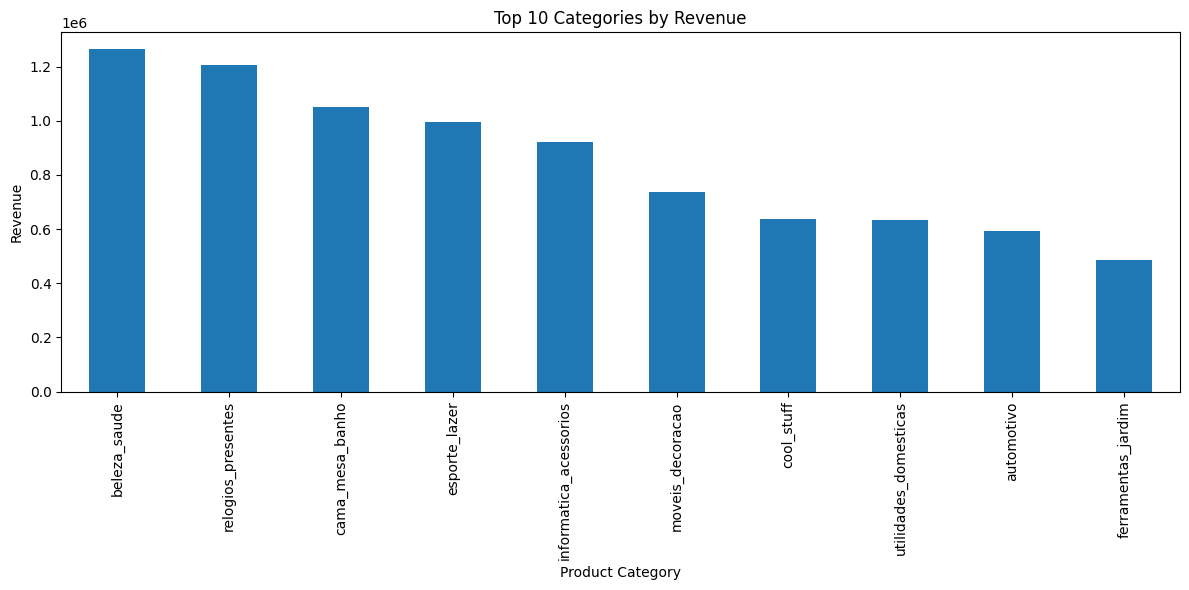

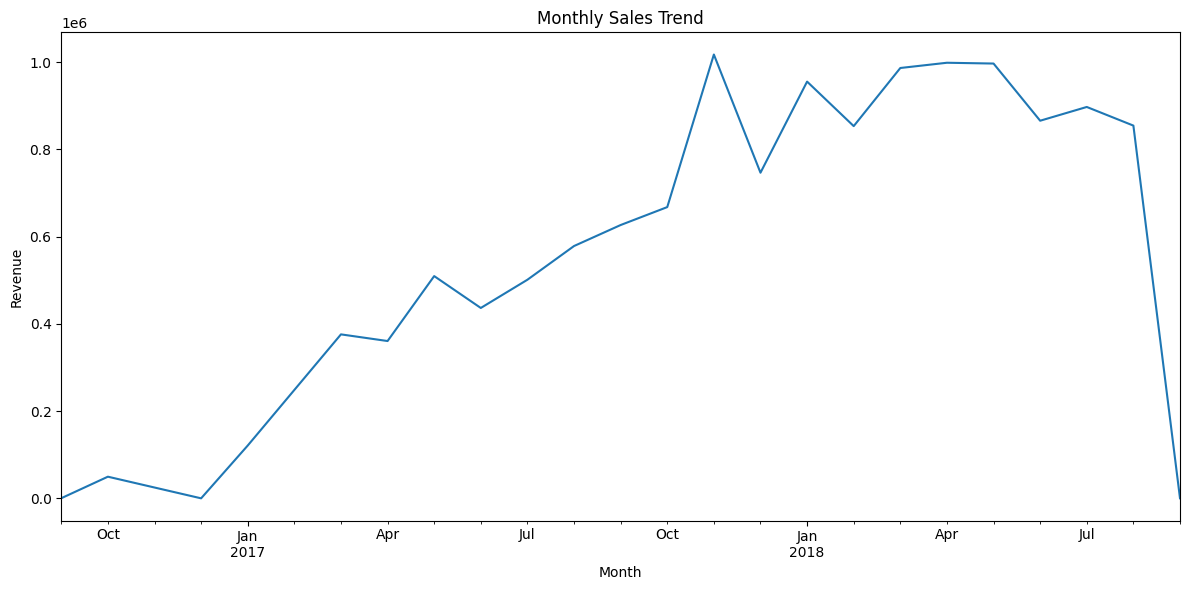

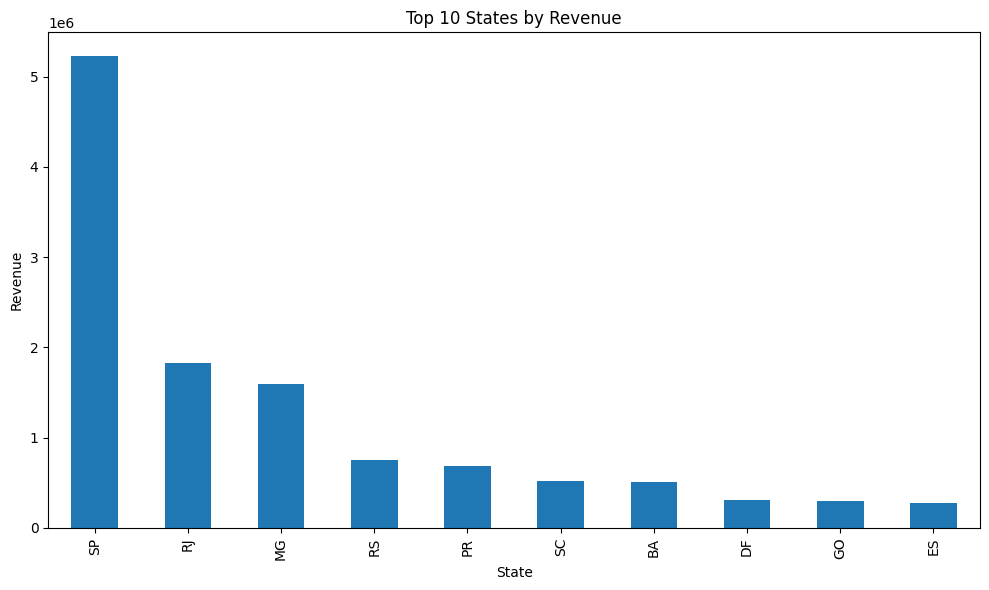

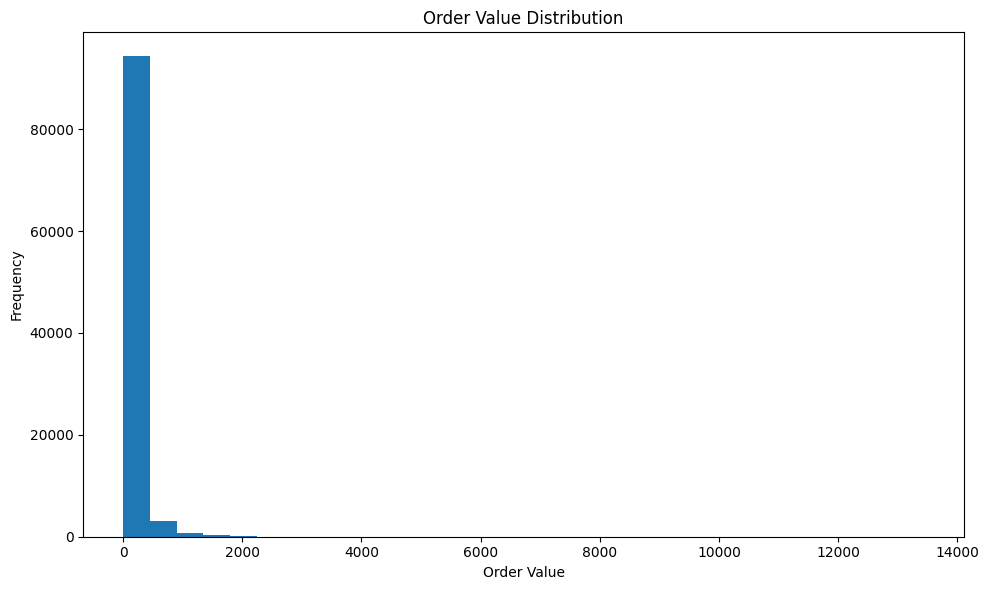

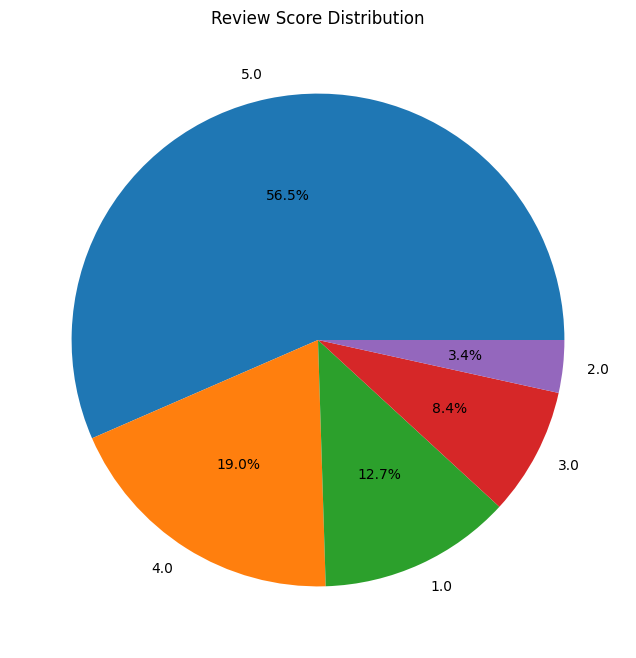

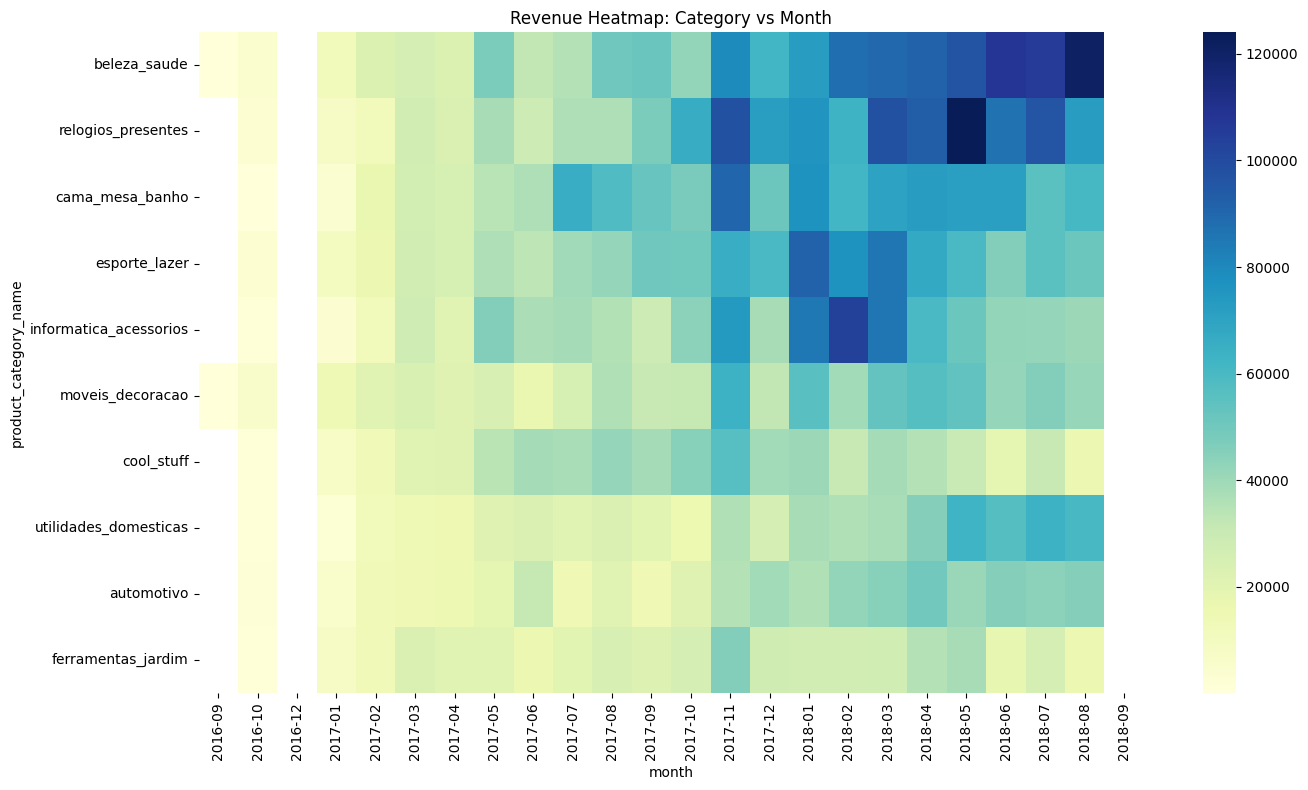

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Revenue by Category
plt.figure(figsize=(12,6))
top_category.head(10).plot(kind='bar')
plt.title('Top 10 Categories by Revenue')
plt.xlabel('Product Category')
plt.ylabel('Revenue')
plt.tight_layout()
plt.show()

# Monthly Sales Trend
monthly_trend = sales.groupby('month')['price'].sum()

plt.figure(figsize=(12,6))
monthly_trend.plot()
plt.title('Monthly Sales Trend')
plt.xlabel('Month')
plt.ylabel('Revenue')
plt.tight_layout()
plt.show()

# Regional Sales
plt.figure(figsize=(10,6))
region_sales.head(10).plot(kind='bar')
plt.title('Top 10 States by Revenue')
plt.xlabel('State')
plt.ylabel('Revenue')
plt.tight_layout()
plt.show()

# Order Value Distribution
order_values = sales.groupby('order_id')['price'].sum()

plt.figure(figsize=(10,6))
plt.hist(order_values, bins=30)
plt.title('Order Value Distribution')
plt.xlabel('Order Value')
plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

# Review Score Distribution
review_counts = sales['review_score'].value_counts()

plt.figure(figsize=(8,8))
review_counts.plot(kind='pie', autopct='%1.1f%%')
plt.title('Review Score Distribution')
plt.ylabel('')
plt.show()

# Category vs Month Heatmap
heatmap_data = pd.pivot_table(
    sales,
    values='price',
    index='product_category_name',
    columns='month',
    aggfunc='sum'
)

top_categories = top_category.head(10).index

plt.figure(figsize=(14,8))
sns.heatmap(
    heatmap_data.loc[top_categories],
    cmap='YlGnBu'
)
plt.title('Revenue Heatmap: Category vs Month')
plt.tight_layout()
plt.show()

In [ ]:
# Average Order Value

avg_order_value = (
    sales.groupby('order_id')['price']
    .sum()
    .mean()
)

print("Average Order Value:", avg_order_value)

# Review Score Distribution

print("\nReview Score Distribution")
print(
    sales['review_score']
    .value_counts()
    .sort_index()
)


Average Order Value: 138.36502412178464

Review Score Distribution
review_score
1.0    14235
2.0     3874
3.0     9423
4.0    21315
5.0    63525
Name: count, dtype: int64


In [ ]:
sales.to_csv('cleaned_data.csv', index=False)

print("File saved successfully!")
from google.colab import files
files.download('cleaned_data.csv')

File saved successfully!


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

# Business Insights Report

## Insight 1: Highest Revenue Category
The Beauty & Health (beleza_saude) category generated the highest revenue among all product categories.

**Recommendation:** Increase inventory levels and marketing campaigns for this category to maximize sales.

---

## Insight 2: Peak Sales Month
November 2017 recorded the highest monthly sales revenue.

**Recommendation:** Launch promotional offers and festive campaigns before November to capitalize on seasonal demand.

---

## Insight 3: Best Performing Region
The state of São Paulo (SP) generated the highest revenue compared to all other states.

**Recommendation:** Strengthen logistics, warehousing, and targeted marketing efforts in São Paulo.

---

## Insight 4: Customer Satisfaction
Most customer reviews received a 5-star rating, indicating strong customer satisfaction.

**Recommendation:** Maintain product quality and customer service standards to preserve positive customer experiences.

---

## Insight 5: Revenue Concentration
A small number of product categories contribute a large share of total revenue.

**Recommendation:** Focus cross-selling and promotional activities on top-performing categories while improving sales in lower-performing categories.

# Most Surprising Finding

The most surprising finding was that the Beauty & Health category generated significantly more revenue than most other categories. Another interesting observation was the large proportion of 5-star customer reviews, showing high customer satisfaction. These results suggest strong customer trust and demand in key product categories.